# Análisis exploratorio de reclamos CFPB

El **análisis exploratorio de datos (EDA)** sirve para entender el archivo antes de transformarlo o entrenar modelos. Cada etapa responde una pregunta y se revisa antes de continuar.

## E0 — Verificar los datos originales

**Pregunta:** ¿Estamos trabajando con el archivo correcto y cuál es su estructura?

Llamamos **datos originales** o `raw` al archivo recibido sin modificaciones. En este paso no transformamos datos ni cargamos las 3.8 millones de narrativas en memoria. Solo revisamos el archivo, su información técnica y cinco registros protegidos. La palabra **corpus** se usará para referirse al conjunto completo de reclamos.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.compute as pc
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from IPython.display import display

### 1. Localizar el archivo original y su referencia DVC

DVC versiona archivos de datos grandes. El archivo `.dvc` es una referencia pequeña que identifica qué versión del Parquet corresponde al proyecto.

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_PATH = PROJECT_ROOT / "data/raw/cfpb_reclamos_narrativa.parquet"
DVC_PATH = PROJECT_ROOT / "data/raw/cfpb_reclamos_narrativa.parquet.dvc"

assert RAW_PATH.exists(), f"No se encontró el raw: {RAW_PATH}"
assert DVC_PATH.exists(), f"No se encontró el puntero DVC: {DVC_PATH}"

dvc_lines = DVC_PATH.read_text(encoding="utf-8").splitlines()
dvc_md5 = next(line.split(":", 1)[1].strip() for line in dvc_lines if line.strip().startswith("- md5:"))

display(pd.DataFrame({
    "campo": ["archivo", "tamaño físico", "MD5 registrado por DVC"],
    "valor": [RAW_PATH.name, f"{RAW_PATH.stat().st_size / 1024**3:.2f} GiB", dvc_md5],
}))

,campo,valor
0,archivo,cfpb_reclamos_narrativa.parquet
1,tamaño físico,1.51 GiB
2,MD5 registrado por DVC,68f4560aca0967779f118e8225e72c26


### 2. Leer la información técnica del Parquet

Un archivo **Parquet** guarda datos en columnas. Sus **metadatos** describen, por ejemplo, cuántas filas y columnas contiene, sin tener que cargar todas las narrativas.

In [3]:
parquet = pq.ParquetFile(RAW_PATH)
metadata = parquet.metadata
logical_bytes = sum(metadata.row_group(i).total_byte_size for i in range(metadata.num_row_groups))

summary = pd.DataFrame({
    "medida": [
        "filas",
        "columnas",
        "grupos de filas",
        "tamaño físico",
        "tamaño lógico Parquet",
        "creado por",
    ],
    "valor": [
        f"{metadata.num_rows:,}",
        metadata.num_columns,
        metadata.num_row_groups,
        f"{RAW_PATH.stat().st_size / 1024**3:.2f} GiB",
        f"{logical_bytes / 1024**3:.2f} GiB",
        metadata.created_by,
    ],
})

assert metadata.num_rows == 3_837_184
assert metadata.num_columns == 16
display(summary)

,medida,valor
0,filas,"3,837,184"
1,columnas,16
2,grupos de filas,83
3,tamaño físico,1.51 GiB
4,tamaño lógico Parquet,3.73 GiB
5,creado por,parquet-cpp-arrow version 24.0.0


### 3. Revisar el esquema del archivo

El **esquema** es la lista de columnas y el tipo con el que cada una está guardada.

In [4]:
schema = parquet.schema_arrow
schema_table = pd.DataFrame({
    "columna": [field.name for field in schema],
    "tipo parquet": [str(field.type) for field in schema],
    "permite nulos": [field.nullable for field in schema],
})
display(schema_table)

,columna,tipo parquet,permite nulos
0,Date received,large_string,True
1,Product,large_string,True
2,Sub-product,large_string,True
3,Issue,large_string,True
4,Sub-issue,large_string,True
5,Consumer complaint narrative,large_string,True
6,Company public response,large_string,True
7,Company,large_string,True
8,State,large_string,True
9,ZIP code,large_string,True


### 4. Verificar cinco registros sin publicar narrativas

La narrativa se reemplaza por su cantidad de caracteres para no guardar texto de consumidores en la salida del notebook.

In [5]:
sample = ds.dataset(RAW_PATH, format="parquet").head(5).to_pandas()
narrative_column = "Consumer complaint narrative"
sample[narrative_column] = sample[narrative_column].map(
    lambda text: f"<narrativa: {len(text):,} caracteres>" if isinstance(text, str) else "<sin narrativa>"
)
display(sample.T)

,0,1,2,3,4
Date received,2023-04-21,2023-07-13,2023-06-27,2024-05-06,2025-06-25
Product,Checking or savings account,"Money transfer, virtual currency, or money ser...",Mortgage,Debt collection,Student loan
Sub-product,Checking account,International money transfer,Other type of mortgage,Auto debt,Federal student loan servicing
Issue,Managing an account,Fraud or scam,Trouble during payment process,Took or threatened to take negative or legal a...,Dealing with your lender or servicer
Sub-issue,Deposits and withdrawals,NaN,NaN,Seized or attempted to seize your property,Trouble with how payments are being handled
Consumer complaint narrative,"<narrativa: 1,094 caracteres>","<narrativa: 1,392 caracteres>","<narrativa: 10,703 caracteres>",<narrativa: 779 caracteres>,"<narrativa: 1,206 caracteres>"
Company public response,Company has responded to the consumer and the ...,Company has responded to the consumer and the ...,Company has responded to the consumer and the ...,NaN,NaN
Company,U.S. BANCORP,"BANK OF AMERICA, NATIONAL ASSOCIATION",Specialized Loan Servicing Holdings LLC,TOYOTA MOTOR CREDIT CORPORATION,MOHELA
State,CA,GA,CA,CA,MA
ZIP code,91362,30032,94954,94112,02360


## Resultado de E0

- El archivo original y su referencia DVC están disponibles.
- El archivo contiene **3,837,184 filas y 16 columnas**.
- La estructura puede inspeccionarse sin cargar todos los reclamos en memoria.
- E0 no modifica el archivo original ni genera otros datos.
- El siguiente paso, sujeto a aprobación, es **E1: revisar tipos, datos ausentes y valores posibles de cada columna**.

## E1 — Revisar tipos, valores ausentes y categorías

**Pregunta:** ¿Qué representa cada columna y qué tan completa está?

Un valor **nulo** indica que el dato está ausente. Una columna **categórica** contiene un conjunto limitado de opciones, como producto o estado. Su **dominio** es la lista de valores diferentes observados. Primero contamos nulos y luego revisamos las categorías más frecuentes.

### 1. Nulos por columna

In [6]:
null_rows = []
for column_index, field in enumerate(schema):
    statistics = [
        metadata.row_group(row_group).column(column_index).statistics
        for row_group in range(metadata.num_row_groups)
    ]
    assert all(stat is not None and stat.null_count is not None for stat in statistics)
    null_count = sum(stat.null_count for stat in statistics)
    null_rows.append({
        "columna": field.name,
        "nulos": null_count,
        "porcentaje": 100 * null_count / metadata.num_rows,
    })

null_table = pd.DataFrame(null_rows).sort_values("nulos", ascending=False, ignore_index=True)
null_display = null_table.copy()
null_display["nulos"] = null_display["nulos"].map("{:,}".format)
null_display["porcentaje"] = null_display["porcentaje"].map("{:.2f}%".format)
display(null_display)

,columna,nulos,porcentaje
0,Tags,"3,469,552",90.42%
1,Company public response,"1,795,421",46.79%
2,Sub-issue,"335,268",8.74%
3,Sub-product,"52,205",1.36%
4,State,"13,718",0.36%
5,ZIP code,290,0.01%
6,Company response to consumer,9,0.00%
7,Date received,0,0.00%
8,Company,0,0.00%
9,Consumer complaint narrative,0,0.00%


### 2. Cómo está guardada cada columna y qué significa

El Parquet guarda las 16 columnas como texto. Sin embargo, una fecha, una categoría y un identificador cumplen funciones distintas y deberán tiparse correctamente después del EDA.

In [7]:
semantic_types = {
    "Date received": "fecha",
    "Product": "categoría",
    "Sub-product": "categoría",
    "Issue": "categoría",
    "Sub-issue": "categoría",
    "Consumer complaint narrative": "texto libre",
    "Company public response": "categoría",
    "Company": "categoría",
    "State": "categoría geográfica",
    "ZIP code": "identificador geográfico",
    "Tags": "categoría",
    "Submitted via": "categoría",
    "Date sent to company": "fecha",
    "Company response to consumer": "categoría / posible objetivo",
    "Timely response?": "binaria / posible objetivo",
    "Complaint ID": "identificador",
}

type_table = schema_table.copy()
type_table["significado esperado"] = type_table["columna"].map(semantic_types)
display(type_table)

,columna,tipo parquet,permite nulos,significado esperado
0,Date received,large_string,True,fecha
1,Product,large_string,True,categoría
2,Sub-product,large_string,True,categoría
3,Issue,large_string,True,categoría
4,Sub-issue,large_string,True,categoría
5,Consumer complaint narrative,large_string,True,texto libre
6,Company public response,large_string,True,categoría
7,Company,large_string,True,categoría
8,State,large_string,True,categoría geográfica
9,ZIP code,large_string,True,identificador geográfico


### 3. Valores posibles de las columnas categóricas

Contamos cuántos valores diferentes tiene cada categoría y mostramos los tres más frecuentes. Cada columna se lee por separado para usar menos memoria.

In [8]:
category_columns = [
    "Product", "Sub-product", "Issue", "Sub-issue",
    "Company public response", "Company", "State", "ZIP code",
    "Tags", "Submitted via", "Company response to consumer",
    "Timely response?",
]

domain_rows = []
for column in category_columns:
    values = pq.read_table(RAW_PATH, columns=[column]).column(0)
    counts = sorted(
        pc.value_counts(values).to_pylist(),
        key=lambda row: row["counts"],
        reverse=True,
    )
    non_null_counts = [row for row in counts if row["values"] is not None]
    top_three = " | ".join(
        f"{str(row['values'])[:45]} ({row['counts']:,})"
        for row in non_null_counts[:3]
    )
    domain_rows.append({
        "columna": column,
        "valores distintos": len(non_null_counts),
        "tres más frecuentes": top_three,
    })

domain_table = pd.DataFrame(domain_rows)
display(domain_table)

,columna,valores distintos,tres más frecuentes
0,Product,21,Credit reporting or other personal consumer r ...
1,Sub-product,85,"Credit reporting (2,457,199) | General-purpose..."
2,Issue,173,"Incorrect information on your report (1,205,00..."
3,Sub-issue,266,"Information belongs to someone else (697,613) ..."
4,Company public response,11,Company has responded to the consumer and the ...
5,Company,6831,"EQUIFAX, INC. (817,318) | TRANSUNION INTERMEDI..."
6,State,63,"TX (485,539) | FL (458,316) | CA (409,800)"
7,ZIP code,6938,"XXXXX (72,506) | 604XX (12,261) | 770XX (11,573)"
8,Tags,3,"Servicemember (240,176) | Older American (98,6..."
9,Submitted via,1,"Web (3,837,184)"


## Resultado de E1

- El archivo almacena las 16 columnas como texto, aunque fechas, categorías e identificadores tienen significados diferentes.
- Los mayores faltantes están en `Tags` (90.42%), `Company public response` (46.79%) y `Sub-issue` (8.74%). No los rellenaremos sin justificar primero qué significa su ausencia.
- `Submitted via` contiene únicamente `Web`; por tanto, no aporta variación en este dataset.
- Hay 21 productos, 173 motivos registrados en `Issue` y 6,831 empresas. Su frecuencia y concentración se estudiarán en E3.
- `Company response to consumer` y `Timely response?` se conocen después de ingresar el reclamo. Pueden ser **objetivos** —resultados que queremos predecir—, pero no **variables de entrada** o `features`.
- E1 describe el archivo original; todavía no cambia tipos ni rellena valores.
- El siguiente paso, sujeto a aprobación, es **E2: cobertura y volumen temporal**.

## E2 — Cobertura y volumen temporal

**Pregunta:** ¿Qué periodo cubren los reclamos y cómo cambia su volumen con el tiempo?

Solo se leen `Date received` y `Date sent to company`. El análisis usa la fecha de recepción para ordenar los eventos. Más adelante dividiremos los datos por periodos: los periodos anteriores servirán para aprender y los posteriores para comprobar si el sistema funciona con reclamos nuevos.

### 1. Convertir y validar las fechas

In [9]:
date_columns = ["Date received", "Date sent to company"]
date_text = pd.read_parquet(RAW_PATH, columns=date_columns, dtype_backend="pyarrow")
dates = date_text.apply(pd.to_datetime, format="%Y-%m-%d", errors="coerce")

date_quality = pd.DataFrame({
    "columna": date_columns,
    "mínimo": [dates[column].min().date() for column in date_columns],
    "máximo": [dates[column].max().date() for column in date_columns],
    "texto nulo": [date_text[column].isna().sum() for column in date_columns],
    "fecha inválida": [
        (dates[column].isna() & date_text[column].notna()).sum()
        for column in date_columns
    ],
})
del date_text
display(date_quality)

,columna,mínimo,máximo,texto nulo,fecha inválida
0,Date received,2015-03-19,2026-07-27,0,0
1,Date sent to company,2015-03-19,2026-08-13,0,0


### 2. Reclamos por año

El primer y el último año pueden estar incompletos dentro del archivo, por lo que no deben compararse directamente con años completos.

In [10]:
received = dates["Date received"]
annual_counts = received.dt.year.value_counts().sort_index()
annual_table = annual_counts.rename_axis("año").reset_index(name="reclamos")
annual_table["porcentaje"] = 100 * annual_table["reclamos"] / len(received)
annual_table["cobertura en el archivo"] = "año completo"
annual_table.loc[annual_table["año"] == received.min().year, "cobertura en el archivo"] = (
    f"desde {received.min().date()}"
)
annual_table.loc[annual_table["año"] == received.max().year, "cobertura en el archivo"] = (
    f"hasta {received.max().date()}"
)
annual_display = annual_table.copy()
annual_display["reclamos"] = annual_display["reclamos"].map("{:,}".format)
annual_display["porcentaje"] = annual_display["porcentaje"].map("{:.2f}%".format)
display(annual_display)

,año,reclamos,porcentaje,cobertura en el archivo
0,2015,"54,723",1.43%,desde 2015-03-19
1,2016,"77,766",2.03%,año completo
2,2017,"115,311",3.01%,año completo
3,2018,"118,393",3.09%,año completo
4,2019,"124,843",3.25%,año completo
5,2020,"174,297",4.54%,año completo
6,2021,"203,570",5.31%,año completo
7,2022,"337,273",8.79%,año completo
8,2023,"487,410",12.70%,año completo
9,2024,"814,384",21.22%,año completo


### 3. Reclamos por mes

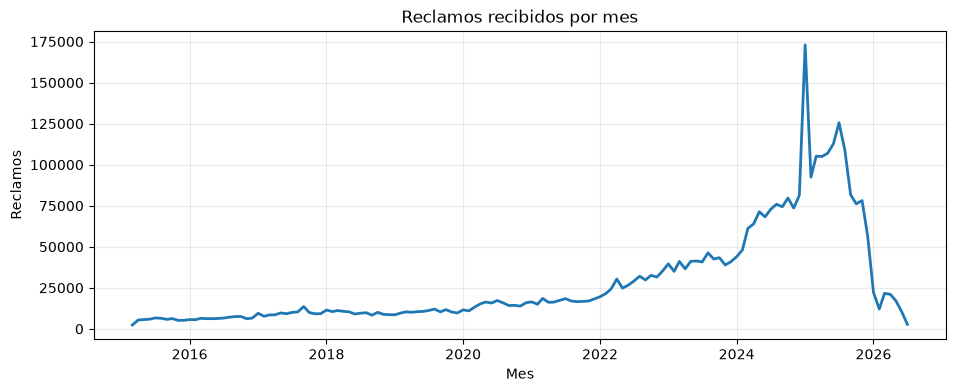

,mes,reclamos
0,2025-08,"108,868"
1,2025-09,"81,659"
2,2025-10,"76,162"
3,2025-11,"78,131"
4,2025-12,"56,510"
5,2026-01,"22,211"
6,2026-02,"12,100"
7,2026-03,"21,603"
8,2026-04,"21,024"
9,2026-05,"17,040"


In [11]:
monthly_counts = received.dt.to_period("M").value_counts().sort_index()
monthly_dates = monthly_counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly_dates, monthly_counts.values, linewidth=2)
ax.set(title="Reclamos recibidos por mes", xlabel="Mes", ylabel="Reclamos")
ax.grid(alpha=0.25)
plt.show()

recent_months = monthly_counts.tail(12).rename_axis("mes").reset_index(name="reclamos")
recent_months["mes"] = recent_months["mes"].astype(str)
recent_months["reclamos"] = recent_months["reclamos"].map("{:,}".format)
display(recent_months)

### 4. Tiempo hasta el envío a la empresa

Este intervalo mide cuándo CFPB envió el reclamo a la empresa. **No es tiempo de resolución ni permite medir el plazo bancario de 15 días hábiles.**

In [12]:
forwarding_days = (dates["Date sent to company"] - received).dt.days
forwarding_summary = pd.DataFrame({
    "medida": [
        "mismo día", "mediana", "percentil 95",
        "máximo", "intervalos negativos",
    ],
    "valor": [
        f"{(forwarding_days == 0).mean():.2%}",
        f"{forwarding_days.median():.0f} días",
        f"{forwarding_days.quantile(0.95):.0f} días",
        f"{forwarding_days.max():.0f} días",
        f"{(forwarding_days < 0).sum():,}",
    ],
})
display(forwarding_summary)

,medida,valor
0,mismo día,93.26%
1,mediana,0 días
2,percentil 95,2 días
3,máximo,1748 días
4,intervalos negativos,0


## Resultado de E2

- Las dos columnas se convierten a fecha sin valores inválidos ni faltantes.
- `Date received` cubre desde 2015-03-19 hasta 2026-07-27; 2015 y 2026 son años parciales dentro del archivo.
- El volumen crece fuertemente: 2025 concentra 1,222,056 reclamos (31.85% del total). Si repartiéramos filas al azar, mezclaríamos años con comportamientos diferentes.
- La reducción observada en 2026 puede deberse a cobertura o retraso de publicación; no demuestra una caída real.
- CFPB envió 93.26% de los reclamos a la empresa el mismo día y 95% en dos días o menos, pero existe un máximo atípico de 1,748 días.
- `Date sent to company` no representa cierre ni resolución y no permite medir el plazo bancario de 15 días.
- La fecha principal para ordenar y dividir los reclamos será `Date received`; los cortes concretos se decidirán en E8.
- El siguiente paso, sujeto a aprobación, es **E3: productos, motivos, empresas y canal de envío**.

## E3 — Productos, motivos, empresas y canal

**Pregunta:** ¿Qué categorías dominan el archivo y cómo se relacionan producto y motivo?

CFPB llama `Issue` al **motivo o tipo de problema** asociado al reclamo. La lista organizada de productos e issues es una **taxonomía**. En este paso conservamos las etiquetas originales. **Canonicalizar** significará, más adelante, agrupar nombres históricos que representan un concepto equivalente.

In [13]:
del dates, received
category_columns = ["Product", "Issue", "Company", "Submitted via"]
categories = pd.read_parquet(RAW_PATH, columns=category_columns, dtype_backend="pyarrow")
categories.shape

(3837184, 4)

### 1. Productos

,producto,reclamos,porcentaje
0,Credit reporting or other personal consumer re...,"1,671,841",43.57%
1,"Credit reporting, credit repair services, or o...","807,499",21.04%
2,Debt collection,"441,051",11.49%
3,Checking or savings account,"186,789",4.87%
4,Mortgage,"146,301",3.81%
5,Credit card,"126,827",3.31%
6,"Money transfer, virtual currency, or money ser...","120,644",3.14%
7,Credit card or prepaid card,"108,683",2.83%
8,Student loan,"62,620",1.63%
9,Vehicle loan or lease,"53,005",1.38%


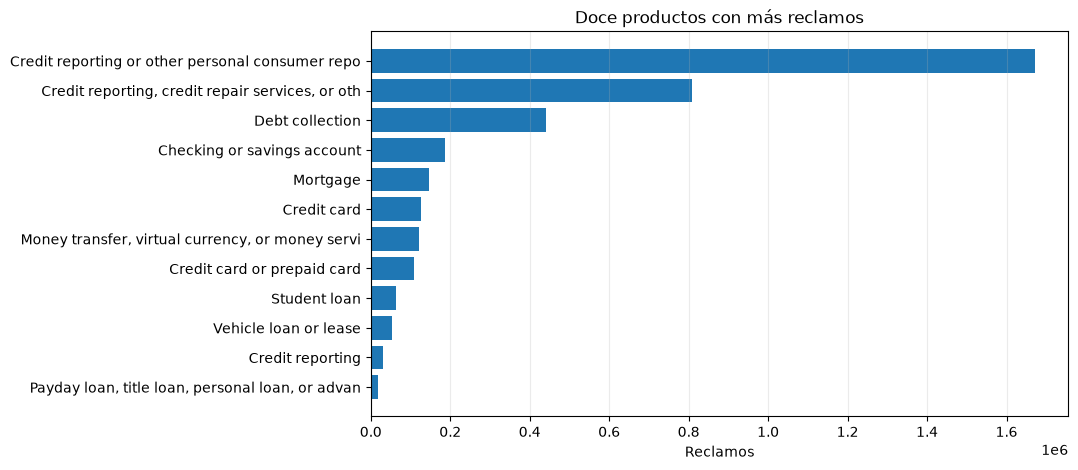

In [14]:
product_counts = categories["Product"].value_counts()
product_table = product_counts.rename_axis("producto").reset_index(name="reclamos")
product_table["porcentaje"] = 100 * product_table["reclamos"] / len(categories)
product_display = product_table.head(12).copy()
product_display["reclamos"] = product_display["reclamos"].map("{:,}".format)
product_display["porcentaje"] = product_display["porcentaje"].map("{:.2f}%".format)
display(product_display)

plot_data = product_table.head(12).sort_values("reclamos")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data["producto"].str.slice(0, 48), plot_data["reclamos"])
ax.set(title="Doce productos con más reclamos", xlabel="Reclamos", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

### 2. Motivos (`Issue`)

`Issue` es el motivo registrado históricamente por CFPB. En nuestro prototipo será un resultado a predecir desde la narrativa, no una variable que asumamos conocida al recibir un reclamo nuevo.

,issue,reclamos,porcentaje
0,Incorrect information on your report,"1,205,002",31.40%
1,Improper use of your report,"664,039",17.31%
2,Problem with a company's investigation into an...,"349,237",9.10%
3,Problem with a credit reporting company's inve...,"250,448",6.53%
4,Attempts to collect debt not owed,"189,403",4.94%
5,Managing an account,"101,759",2.65%
6,Written notification about debt,"88,658",2.31%
7,Trouble during payment process,"56,347",1.47%
8,Other transaction problem,"54,759",1.43%
9,Problem with a purchase shown on your statement,"54,510",1.42%


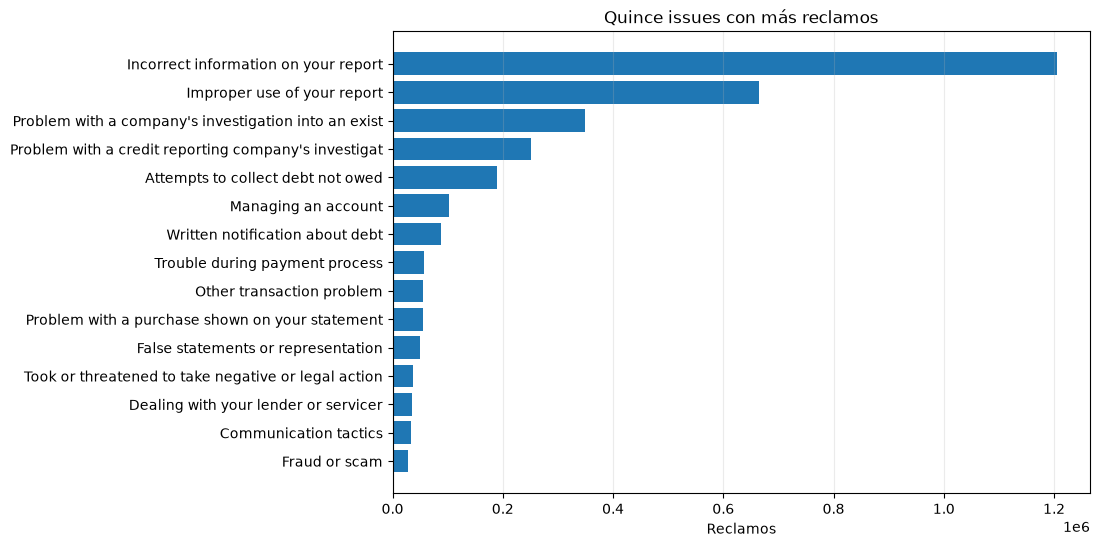

In [15]:
issue_counts = categories["Issue"].value_counts()
issue_table = issue_counts.rename_axis("issue").reset_index(name="reclamos")
issue_table["porcentaje"] = 100 * issue_table["reclamos"] / len(categories)
issue_display = issue_table.head(15).copy()
issue_display["reclamos"] = issue_display["reclamos"].map("{:,}".format)
issue_display["porcentaje"] = issue_display["porcentaje"].map("{:.2f}%".format)
display(issue_display)

plot_data = issue_table.head(15).sort_values("reclamos")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_data["issue"].str.slice(0, 52), plot_data["reclamos"])
ax.set(title="Quince issues con más reclamos", xlabel="Reclamos", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

### 3. Relación entre producto y motivo

Mostramos cuántos motivos aparecen en cada producto y qué porcentaje representa el motivo más frecuente de ese producto.

In [16]:
product_issue = (
    categories.groupby(["Product", "Issue"], observed=True)
    .size()
    .rename("reclamos")
    .reset_index()
)
issues_per_product = product_issue.groupby("Product")["Issue"].size().rename("issues distintos")
top_issue = (
    product_issue.sort_values(["Product", "reclamos"], ascending=[True, False])
    .drop_duplicates("Product")
    .set_index("Product")
)
product_issue_summary = pd.concat([issues_per_product, top_issue[["Issue", "reclamos"]]], axis=1)
product_issue_summary["porcentaje del producto"] = (
    100 * product_issue_summary["reclamos"] / product_counts
)
product_issue_summary = (
    product_issue_summary.rename(columns={"Issue": "issue más frecuente"})
    .sort_values("reclamos", ascending=False)
    .reset_index(names="producto")
)
product_issue_display = product_issue_summary.copy()
product_issue_display["reclamos"] = product_issue_display["reclamos"].map("{:,}".format)
product_issue_display["porcentaje del producto"] = product_issue_display["porcentaje del producto"].map("{:.2f}%".format)
display(product_issue_display)

,producto,issues distintos,issue más frecuente,reclamos,porcentaje del producto
0,Credit reporting or other personal consumer re...,13,Incorrect information on your report,"830,986",49.70%
1,"Credit reporting, credit repair services, or o...",30,Incorrect information on your report,"353,734",43.81%
2,Debt collection,11,Attempts to collect debt not owed,"189,403",42.94%
3,Checking or savings account,13,Managing an account,"101,759",54.48%
4,Mortgage,16,Trouble during payment process,"56,345",38.51%
5,"Money transfer, virtual currency, or money ser...",17,Other transaction problem,"54,759",45.39%
6,Student loan,14,Dealing with your lender or servicer,"34,911",55.75%
7,Credit card,45,Problem with a purchase shown on your statement,"28,348",22.35%
8,Credit card or prepaid card,22,Problem with a purchase shown on your statement,"26,160",24.07%
9,Credit reporting,5,Incorrect information on credit report,"21,216",67.17%


### 4. Empresas

Un modelo puede obtener mejores resultados en CFPB si aprende qué suele ocurrir en cada empresa. Sin embargo, ese aprendizaje puede no servir dentro de un banco donde la empresa es siempre la misma.

In [17]:
company_counts = categories["Company"].value_counts()
company_table = company_counts.rename_axis("empresa").reset_index(name="reclamos")
company_table["porcentaje"] = 100 * company_table["reclamos"] / len(categories)
company_table["porcentaje acumulado"] = company_table["porcentaje"].cumsum()
company_display = company_table.head(15).copy()
company_display["reclamos"] = company_display["reclamos"].map("{:,}".format)
company_display["porcentaje"] = company_display["porcentaje"].map("{:.2f}%".format)
company_display["porcentaje acumulado"] = company_display["porcentaje acumulado"].map("{:.2f}%".format)
display(company_display)

concentration = pd.DataFrame({
    "grupo": ["empresa principal", "10 principales", "100 principales"],
    "porcentaje de reclamos": [
        company_counts.iloc[:1].sum() / len(categories),
        company_counts.iloc[:10].sum() / len(categories),
        company_counts.iloc[:100].sum() / len(categories),
    ],
})
concentration["porcentaje de reclamos"] = concentration["porcentaje de reclamos"].map("{:.2%}".format)
display(concentration)

,empresa,reclamos,porcentaje,porcentaje acumulado
0,"EQUIFAX, INC.","817,318",21.30%,21.30%
1,"TRANSUNION INTERMEDIATE HOLDINGS, INC.","775,030",20.20%,41.50%
2,Experian Information Solutions Inc.,"737,722",19.23%,60.72%
3,CAPITAL ONE FINANCIAL CORPORATION,"70,826",1.85%,62.57%
4,JPMORGAN CHASE & CO.,"65,005",1.69%,64.26%
5,WELLS FARGO & COMPANY,"60,724",1.58%,65.85%
6,"BANK OF AMERICA, NATIONAL ASSOCIATION","58,743",1.53%,67.38%
7,"CITIBANK, N.A.","55,558",1.45%,68.82%
8,"Block, Inc.","48,634",1.27%,70.09%
9,SYNCHRONY FINANCIAL,"35,130",0.92%,71.01%


,grupo,porcentaje de reclamos
0,empresa principal,21.30%
1,10 principales,71.01%
2,100 principales,88.95%


### 5. Canal disponible

In [18]:
channel_table = categories["Submitted via"].value_counts().rename_axis("canal").reset_index(name="reclamos")
channel_table["porcentaje"] = 100 * channel_table["reclamos"] / len(categories)
display(channel_table)

,canal,reclamos,porcentaje
0,Web,3837184,100.0


## Resultado de E3

- Las tres etiquetas relacionadas con credit reporting concentran aproximadamente 65.43% de los reclamos. Además, nombres como `Credit card` y `Credit card or prepaid card` evidencian cambios históricos de taxonomía.
- Los dos motivos principales reúnen 48.71% de los reclamos. Como pocas categorías concentran gran parte de los casos, el porcentaje global de aciertos podría ocultar un mal resultado en motivos poco frecuentes.
- La relación entre producto y motivo debe conservarse porque el motivo dominante cambia según el producto.
- `Fraud or scam` aparece en 28,291 reclamos (0.74%), pero es una categoría declarada y no fraude confirmado.
- Las tres empresas principales concentran 60.72% de los reclamos y las diez primeras 71.01%. Debemos probar el modelo con y sin `Company` antes de afirmar que funcionaría en otro contexto.
- `Issue` puede ser un resultado a predecir, pero no una variable de entrada para un reclamo nuevo.
- `Submitted via` es `Web` en 100% del archivo y no debe convertirse en variable de entrada.
- E3 aporta evidencia para canonicalizar categorías en E9, pero todavía conserva todas las etiquetas originales.
- El siguiente paso, sujeto a aprobación, es **E4: respuestas de la empresa y posibles objetivos**.

## E4 — Respuestas de la empresa y resultados a predecir

**Pregunta:** ¿Qué resultados históricos podemos usar como etiquetas sin mezclarlos con la información disponible al inicio?

Una **etiqueta** es el resultado conocido en los datos históricos que queremos aprender a predecir. Estas columnas describen lo ocurrido después del reclamo, así que pueden ser etiquetas, pero nunca variables de entrada del mismo modelo.

In [19]:
del categories
response_columns = ["Company response to consumer", "Timely response?"]
responses = pd.read_parquet(RAW_PATH, columns=response_columns, dtype_backend="pyarrow")
responses.shape

(3837184, 2)

### 1. Respuestas registradas

,respuesta,reclamos,porcentaje
0,Closed with explanation,"2,548,866",66.425%
1,Closed with non-monetary relief,"1,175,215",30.627%
2,Closed with monetary relief,"98,150",2.558%
3,Untimely response,"11,092",0.289%
4,Closed,"3,741",0.097%
5,In progress,111,0.003%
6,<NA>,9,0.000%


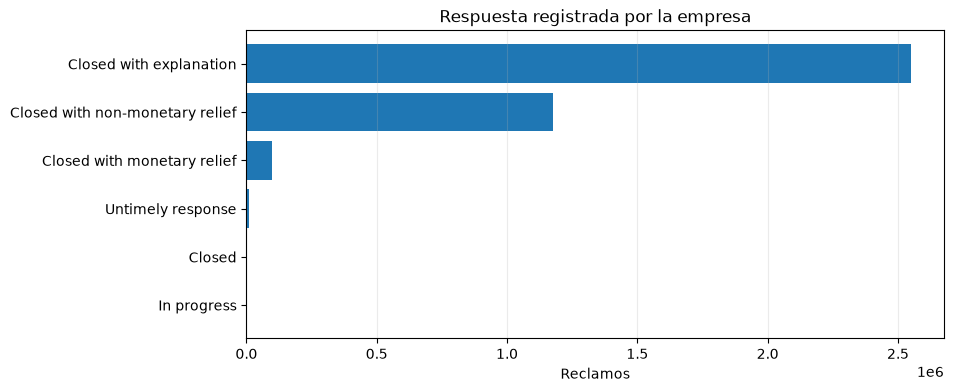

In [20]:
response_counts = responses["Company response to consumer"].value_counts(dropna=False)
response_table = response_counts.rename_axis("respuesta").reset_index(name="reclamos")
response_table["porcentaje"] = 100 * response_table["reclamos"] / len(responses)
response_display = response_table.copy()
response_display["reclamos"] = response_display["reclamos"].map("{:,}".format)
response_display["porcentaje"] = response_display["porcentaje"].map("{:.3f}%".format)
display(response_display)

plot_data = response_table.dropna(subset=["respuesta"]).sort_values("reclamos")
fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(plot_data["respuesta"], plot_data["reclamos"])
ax.set(title="Respuesta registrada por la empresa", xlabel="Reclamos", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

### 2. Reglas candidatas para T1, T2, T3 y T4

Usamos nombres cortos para cuatro resultados posibles:

- **T1:** motivo del reclamo (`Issue`).
- **T2:** si se registró alguna solución o compensación.
- **T3:** si se registró una compensación monetaria.
- **T4:** si CFPB marcó la respuesta como no oportuna.

CFPB usa la palabra **relief** para registrar una solución o compensación. Puede ser monetaria —por ejemplo, devolución de dinero— o no monetaria —por ejemplo, corregir un registro—. Para T2 y T3 solo usamos respuestas cuyo significado es explícito:

| Respuesta histórica | T2: algún relief | T3: relief monetario |
|---|---:|---:|
| `Closed with monetary relief` | Sí | Sí |
| `Closed with non-monetary relief` | Sí | No |
| `Closed with explanation` | No | No |
| Cualquier otra respuesta o nulo | Desconocido | Desconocido |

`Closed with explanation` sí participa. Es un ejemplo **negativo**, es decir, un caso donde no se registró relief monetario ni no monetario. No significa que la respuesta haya sido mala.

In [21]:
response = responses["Company response to consumer"]
explicit_responses = [
    "Closed with monetary relief",
    "Closed with non-monetary relief",
    "Closed with explanation",
]
eligible = response.isin(explicit_responses)

targets = pd.DataFrame(index=responses.index)
targets["T2_relief"] = pd.Series(pd.NA, index=responses.index, dtype="boolean")
targets.loc[eligible, "T2_relief"] = response[eligible].isin(explicit_responses[:2]).to_numpy()
targets["T3_monetary_relief"] = pd.Series(pd.NA, index=responses.index, dtype="boolean")
targets.loc[eligible, "T3_monetary_relief"] = response[eligible].eq(explicit_responses[0]).to_numpy()
targets["T4_untimely"] = responses["Timely response?"].eq("No").astype("boolean")

assert targets.loc[targets["T3_monetary_relief"].eq(True), "T2_relief"].all()
targets.head()

,T2_relief,T3_monetary_relief,T4_untimely
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,True


### 3. Balance de los resultados a predecir

La **clase positiva** es el evento que queremos detectar, por ejemplo relief monetario. Revisamos qué tan frecuente es frente a la clase negativa.

,objetivo,positivos,negativos,desconocidos,tasa positiva
0,T2 — algún relief,"1,273,365","2,548,866","14,953",33.315%
1,T3 — relief monetario,"98,150","3,724,081","14,953",2.568%
2,T4 — respuesta no oportuna CFPB,"42,615","3,794,569",0,1.111%


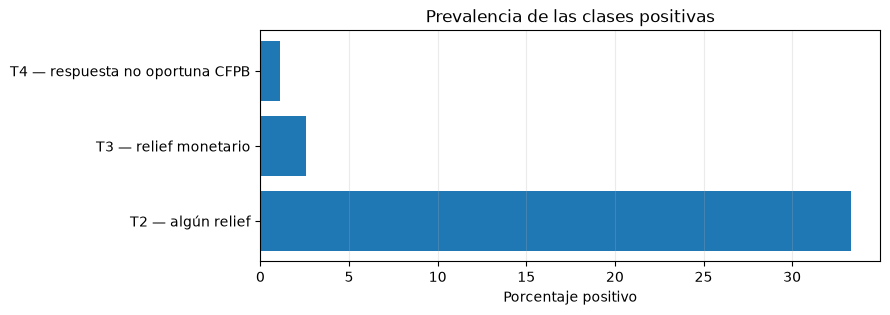

Timely response?,No,Yes,All
Company response to consumer,,,
<nulo>,0,9,9
Closed,536,3205,3741
Closed with explanation,28271,2520595,2548866
Closed with monetary relief,1180,96970,98150
Closed with non-monetary relief,1536,1173679,1175215
In progress,0,111,111
Untimely response,11092,0,11092
All,42615,3794569,3837184


In [22]:
target_names = {
    "T2_relief": "T2 — algún relief",
    "T3_monetary_relief": "T3 — relief monetario",
    "T4_untimely": "T4 — respuesta no oportuna CFPB",
}
target_rows = []
for column, name in target_names.items():
    values = targets[column]
    known = values.notna()
    positives = values.eq(True).sum()
    negatives = values.eq(False).sum()
    target_rows.append({
        "objetivo": name,
        "positivos": positives,
        "negativos": negatives,
        "desconocidos": (~known).sum(),
        "tasa positiva": 100 * positives / known.sum(),
    })

target_table = pd.DataFrame(target_rows)
target_display = target_table.copy()
for column in ["positivos", "negativos", "desconocidos"]:
    target_display[column] = target_display[column].map("{:,}".format)
target_display["tasa positiva"] = target_display["tasa positiva"].map("{:.3f}%".format)
display(target_display)

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(target_table["objetivo"], target_table["tasa positiva"])
ax.set(title="Prevalencia de las clases positivas", xlabel="Porcentaje positivo", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

timeliness_by_response = pd.crosstab(
    responses["Company response to consumer"].fillna("<nulo>"),
    responses["Timely response?"],
    margins=True,
)
display(timeliness_by_response)

### 4. Qué información puede usar el modelo

Existe **fuga de información** cuando el modelo recibe un dato que solo se conoce después del resultado que intenta predecir. Eso produciría métricas artificialmente altas.

| Campo | Uso permitido | Motivo |
|---|---|---|
| `Issue` | Objetivo T1 | Se asignó históricamente; no se asume conocido al ingreso |
| `Company response to consumer` | Construir T2 y T3 | Ocurre después de la respuesta |
| `Timely response?` | Construir T4 | Ocurre después de la respuesta |
| `Company public response` | No usar como variable de entrada | Texto posterior que puede revelar el resultado |
| `Date sent to company` | Análisis del proceso CFPB | No es fecha de cierre y puede no existir al ingreso |

## Resultado de E4

- T2 y T3 usan 3,822,231 respuestas explícitas; 14,953 respuestas ambiguas permanecen como resultado desconocido en vez de tratarlas incorrectamente como negativas.
- T2 tiene 1,273,365 positivos (33.315%) y T3 tiene 98,150 (2.568%). Todo caso positivo de T3 también es positivo de T2.
- `Closed with explanation` representa 66.425% del total y es el negativo explícito de T2 y T3.
- T4 tiene 42,615 positivos (1.111%). Debe derivarse de `Timely response? = No`, no de la categoría `Untimely response`, que solo aparece 11,092 veces.
- T4 mide la respuesta oportuna reportada por CFPB; no mide resolución ni el plazo bancario de 15 días.
- Ninguna columna usada para construir T1–T4 puede entrar como variable de entrada del mismo objetivo.
- El siguiente paso, sujeto a aprobación, es **E5: calidad y longitud de las narrativas**.

## E5 — Calidad y longitud del texto del consumidor

**Pregunta:** ¿Las narrativas contienen texto utilizable y qué longitud deberá soportar el modelo?

La **narrativa** es el texto libre escrito por el consumidor. No publicamos ese texto: solo calculamos resúmenes sobre el conjunto completo.

In [23]:
import gc
import re

del responses, response, targets, values, eligible
gc.collect()

narrative_column = "Consumer complaint narrative"
narratives = pd.read_parquet(
    RAW_PATH, columns=[narrative_column], dtype_backend="pyarrow"
)[narrative_column]
narratives.shape

(3837184,)

### 1. Vacíos y longitud

Un **percentil** resume una distribución. Por ejemplo, percentil 95 de 518 palabras significa que 95% de las narrativas tiene 518 palabras o menos.

In [24]:
empty_narratives = narratives.str.fullmatch(r"\s*").fillna(False).sum()
character_count = narratives.str.len()
word_count = narratives.str.count(r"\S+")

quantiles = [0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00]
length_table = pd.DataFrame({
    "percentil": [f"{value:.0%}" for value in quantiles],
    "caracteres": character_count.quantile(quantiles).round().astype("int64").to_numpy(),
    "palabras aproximadas": word_count.quantile(quantiles).round().astype("int64").to_numpy(),
})
display(length_table)

,percentil,caracteres,palabras aproximadas
0,0%,4,1
1,1%,63,11
2,5%,127,22
3,25%,346,61
4,50%,669,117
5,75%,1221,214
6,95%,3002,518
7,99%,5873,1021
8,100%,35984,6469


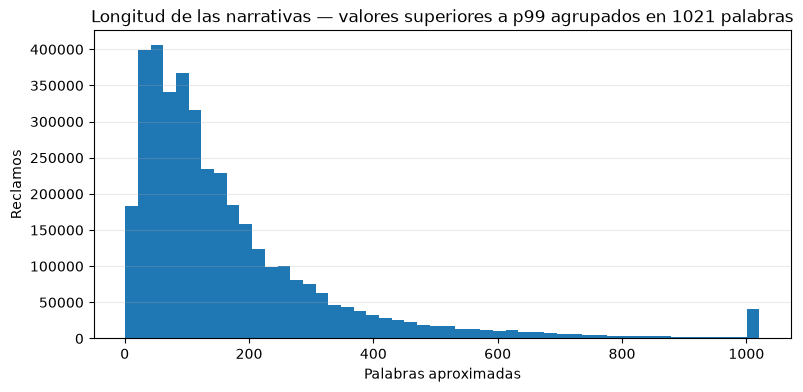

In [25]:
word_limit = int(word_count.quantile(0.99))
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(word_count.clip(upper=word_limit).to_numpy(), bins=50)
ax.set(
    title=f"Longitud de las narrativas — valores superiores a p99 agrupados en {word_limit} palabras",
    xlabel="Palabras aproximadas",
    ylabel="Reclamos",
)
ax.grid(axis="y", alpha=0.25)
plt.show()

### 2. Señales simples de calidad

Un **encoder** transforma texto en números que un modelo puede usar. Lee unidades llamadas **tokens**, que pueden ser palabras o fragmentos de palabras. Si el texto supera su límite, debe recortarse —**truncamiento**— o dividirse en fragmentos. Más de 400 palabras es solo una alerta aproximada porque palabras y tokens no son equivalentes.

In [26]:
quality_metrics = pd.DataFrame({
    "señal": [
        "narrativa nula",
        "vacía después de quitar espacios",
        "menos de 20 palabras",
        "más de 400 palabras",
        "contiene XXXX de anonimización",
        "contiene salto de línea",
    ],
    "reclamos": [
        narratives.isna().sum(),
        empty_narratives,
        (word_count < 20).sum(),
        (word_count > 400).sum(),
        narratives.str.contains("XXXX", regex=False, na=False).sum(),
        narratives.str.contains("\n", regex=False, na=False).sum(),
    ],
})
quality_metrics["porcentaje"] = 100 * quality_metrics["reclamos"] / len(narratives)
quality_display = quality_metrics.copy()
quality_display["reclamos"] = quality_display["reclamos"].map("{:,}".format)
quality_display["porcentaje"] = quality_display["porcentaje"].map("{:.2f}%".format)
display(quality_display)

,señal,reclamos,porcentaje
0,narrativa nula,0,0.00%
1,vacía después de quitar espacios,0,0.00%
2,menos de 20 palabras,"157,017",4.09%
3,más de 400 palabras,"323,582",8.43%
4,contiene XXXX de anonimización,"2,593,664",67.59%
5,contiene salto de línea,"1,564,092",40.76%


### 3. Idioma aparente en una muestra

La siguiente regla compara palabras comunes en inglés y español usando siempre las mismas 20,000 narrativas. Es una **heurística**, es decir, una regla simple para orientar la revisión; no es una etiqueta confiable ni una variable de entrada.

In [27]:
english_markers = {"the", "and", "to", "of", "is", "was", "that", "with", "for", "my", "on", "account", "company"}
spanish_markers = {"el", "la", "los", "las", "de", "que", "y", "en", "mi", "con", "para", "cuenta", "empresa"}

def language_hint(text):
    words = re.findall(r"[a-záéíóúüñ]+", text.lower())
    english_score = sum(word in english_markers for word in words)
    spanish_score = sum(word in spanish_markers for word in words)
    if english_score >= 5 and english_score >= 2 * spanish_score:
        return "inglés aparente"
    if spanish_score >= 5 and spanish_score >= 2 * english_score:
        return "español aparente"
    return "indeterminado"

sample_size = 20_000
step = max(len(narratives) // sample_size, 1)
language_sample = narratives.iloc[::step].head(sample_size)
language_counts = language_sample.map(language_hint).value_counts()
language_table = language_counts.rename_axis("resultado").reset_index(name="narrativas")
language_table["porcentaje"] = 100 * language_table["narrativas"] / len(language_sample)
language_table["porcentaje"] = language_table["porcentaje"].map("{:.2f}%".format)
display(language_table)

,resultado,narrativas,porcentaje
0,inglés aparente,18776,93.88%
1,indeterminado,1224,6.12%


## Resultado de E5

- No existen narrativas nulas o vacías después de retirar espacios.
- La mitad de las narrativas tiene 117 palabras o menos; 95% tiene 518 o menos y 99% tiene 1,021 o menos. El máximo es 6,469.
- 323,582 narrativas (8.43%) superan 400 palabras. Un modelo de texto con longitud limitada necesitará decidir si recorta el final o divide el texto en fragmentos.
- 157,017 narrativas (4.09%) tienen menos de 20 palabras y pueden aportar poco contexto, aunque no se eliminarán automáticamente.
- `XXXX` aparece en 2,593,664 narrativas (67.59%); es anonimización y deberá normalizarse consistentemente, no interpretarse como una palabra.
- En la muestra de 20,000 textos, 93.88% parece inglés y 6.12% queda indeterminado. Ningún texto superó el umbral de español, pero esta regla simple no demuestra que todo el conjunto esté en inglés.
- El siguiente paso, sujeto a aprobación, es **E6: IDs duplicados y narrativas repetidas**.

## E6 — Reclamos duplicados y textos repetidos

**Pregunta:** ¿Existen eventos duplicados o textos reutilizados que puedan aparecer tanto en entrenamiento como en evaluación?

Un **ID duplicado** indicaría que el mismo reclamo aparece más de una vez. Un **texto repetido** indica que eventos con IDs distintos comparten una narrativa. Repetición no significa error: conservamos todos los reclamos y agrupamos los textos para evitar una evaluación engañosa.

In [28]:
del character_count, word_count, language_sample
gc.collect()

identity = pd.read_parquet(
    RAW_PATH, columns=["Complaint ID", "Date received"], dtype_backend="pyarrow"
)
identity["Date received"] = pd.to_datetime(identity["Date received"], format="%Y-%m-%d")
identity.shape

(3837184, 2)

### 1. Identificadores repetidos

In [29]:
duplicate_id_mask = identity["Complaint ID"].duplicated(keep=False)
id_summary = pd.DataFrame({
    "medida": ["filas", "IDs únicos", "filas con ID repetido"],
    "valor": [len(identity), identity["Complaint ID"].nunique(), duplicate_id_mask.sum()],
})
id_summary["valor"] = id_summary["valor"].map("{:,}".format)
display(id_summary)

,medida,valor
0,filas,"3,837,184"
1,IDs únicos,"3,837,184"
2,filas con ID repetido,0


### 2. Texto exacto y texto normalizado

**Normalizar** significa aplicar reglas exactas para comparar textos. `text_normalizer_v1` ejecuta, en este orden: Unicode NFKC; minúsculas Unicode con `casefold`; reemplazo del patrón `\bx{2,}\b` por el texto literal `<redacted>`; reemplazo de `\s+` por un espacio; y retiro de espacios al inicio o final. El patrón exige dos o más `x` delimitadas como una palabra completa, por lo que no modifica `xx` dentro de palabras. Tampoco elimina números ni puntuación.

Un **hash** es un identificador numérico calculado desde el texto. Textos iguales producen el mismo hash y pueden agruparse sin mostrar la narrativa.

In [30]:
exact_hash = pd.util.hash_pandas_object(narratives, index=False)
exact_counts = exact_hash.value_counts()

NORMALIZER_VERSION = "text_normalizer_v1"
normalized_narratives = (
    narratives.str.normalize("NFKC")
    .str.casefold()
    .str.replace(r"\bx{2,}\b", "<redacted>", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)
normalized_hash = pd.util.hash_pandas_object(normalized_narratives, index=False)
normalized_counts = normalized_hash.value_counts()
del normalized_narratives
gc.collect()

def repetition_row(name, counts):
    repeated = counts[counts > 1]
    return {
        "comparación": name,
        "grupos únicos": len(counts),
        "grupos repetidos": len(repeated),
        "filas en grupos repetidos": repeated.sum(),
        "repeticiones adicionales": (repeated - 1).sum(),
        "grupo máximo": counts.max(),
    }

repetition_table = pd.DataFrame([
    repetition_row("texto exacto", exact_counts),
    repetition_row("texto normalizado", normalized_counts),
])
repetition_table["porcentaje de filas repetidas"] = (
    100 * repetition_table["filas en grupos repetidos"] / len(narratives)
)
repetition_display = repetition_table.copy()
for column in ["grupos únicos", "grupos repetidos", "filas en grupos repetidos", "repeticiones adicionales", "grupo máximo"]:
    repetition_display[column] = repetition_display[column].map("{:,}".format)
repetition_display["porcentaje de filas repetidas"] = repetition_display["porcentaje de filas repetidas"].map("{:.2f}%".format)
display(repetition_display)

,comparación,grupos únicos,grupos repetidos,filas en grupos repetidos,repeticiones adicionales,grupo máximo,porcentaje de filas repetidas
0,texto exacto,"2,583,683","246,105","1,499,606","1,253,501","27,496",39.08%
1,texto normalizado,"2,476,614","281,943","1,642,513","1,360,570","30,110",42.81%


### 3. Tamaño de los grupos normalizados

In [31]:
repeated_sizes = normalized_counts[normalized_counts > 1]
size_bands = pd.cut(
    repeated_sizes,
    bins=[1, 2, 5, 10, float("inf")],
    labels=["2", "3 a 5", "6 a 10", "más de 10"],
    include_lowest=True,
)
group_size_table = size_bands.value_counts(sort=False).rename_axis("tamaño del grupo").reset_index(name="grupos")
group_size_table["grupos"] = group_size_table["grupos"].map("{:,}".format)
display(group_size_table)

,tamaño del grupo,grupos
0,2,"139,684"
1,3 a 5,"125,857"
2,6 a 10,"8,798"
3,más de 10,"7,604"


### 4. Repetición a través del tiempo

Una **división temporal** o `split` separa periodos: unos para entrenar y otros para evaluar. Si el mismo texto aparece en ambos lados, el modelo puede memorizarlo y parecer mejor de lo que realmente es.

In [32]:
def temporal_repetition(name, hashes, counts):
    repeated_hashes = counts.index[counts > 1]
    repeated_mask = hashes.isin(repeated_hashes)
    spans = (
        pd.DataFrame({"hash": hashes[repeated_mask], "date": identity.loc[repeated_mask, "Date received"]})
        .groupby("hash")["date"]
        .agg(["size", "min", "max"])
    )
    span_days = (spans["max"] - spans["min"]).dt.days
    return {
        "comparación": name,
        "grupos repetidos": len(spans),
        "grupos en más de una fecha": (span_days > 0).sum(),
        "grupos en más de un año": (spans["min"].dt.year != spans["max"].dt.year).sum(),
        "máximo intervalo": f"{span_days.max():,} días",
    }

temporal_table = pd.DataFrame([
    temporal_repetition("texto exacto", exact_hash, exact_counts),
    temporal_repetition("texto normalizado", normalized_hash, normalized_counts),
])
for column in ["grupos repetidos", "grupos en más de una fecha", "grupos en más de un año"]:
    temporal_table[column] = temporal_table[column].map("{:,}".format)
display(temporal_table)

,comparación,grupos repetidos,grupos en más de una fecha,grupos en más de un año,máximo intervalo
0,texto exacto,"246,105","37,463","7,155","3,347 días"
1,texto normalizado,"281,943","40,598","7,980","3,347 días"


## E6.1 — Describir los patrones de repetición

**Pregunta:** ¿Los textos repetidos aparecen durante periodos amplios y en varias empresas, o se concentran en pocos días dentro de una empresa y producto?

Una **plantilla** es un texto reutilizado durante un periodo amplio. Una **ráfaga** es una concentración de casos similares en pocos días. Las siguientes señales son aproximadas, pueden solaparse y no demuestran quién creó el texto ni que exista fraude.

In [33]:
del narratives
gc.collect()

context = pd.read_parquet(
    RAW_PATH, columns=["Company", "Product", "Issue"], dtype_backend="pyarrow"
)
repeated_hashes = normalized_counts.index[normalized_counts > 1]
repeated_mask = normalized_hash.isin(repeated_hashes)
context = context.loc[repeated_mask].copy()
context["hash"] = normalized_hash.loc[repeated_mask]
context["date"] = identity.loc[repeated_mask, "Date received"]
context.shape

(1642513, 5)

### 1. Perfil por grupo repetido

In [34]:
group_profile = context.groupby("hash").agg(
    size=("hash", "size"),
    companies=("Company", "nunique"),
    products=("Product", "nunique"),
    issues=("Issue", "nunique"),
    first_date=("date", "min"),
    last_date=("date", "max"),
)
group_profile["span_days"] = (group_profile["last_date"] - group_profile["first_date"]).dt.days

for column, prefix in [("Company", "company"), ("Product", "product"), ("Issue", "issue")]:
    counts = context.groupby(["hash", column]).size().rename("count").reset_index()
    dominant = (
        counts.sort_values(["hash", "count"], ascending=[True, False])
        .drop_duplicates("hash")
        .set_index("hash")
    )
    group_profile[f"dominant_{prefix}"] = dominant[column]
    group_profile[f"{prefix}_share"] = dominant["count"] / group_profile["size"]

daily_counts = context.groupby(["hash", "date"]).size()
group_profile["largest_day_share"] = daily_counts.groupby("hash").max() / group_profile["size"]
group_profile.shape

(281943, 14)

### 2. Reglas exploratorias

- **Posible plantilla:** el mismo texto aparece en más de una empresa y durante más de 30 días.
- **Posible ráfaga localizada:** dentro del mismo grupo de texto normalizado, al menos cinco reclamos corresponden a la misma empresa y producto y fueron recibidos en un máximo de siete días.
- **Repetición prolongada:** el mismo texto reaparece después de más de un año.

Los límites de 30, 7 y 365 días son decisiones para explorar los datos. No son reglas que un banco deba adoptar.

In [35]:
signals = {
    "mismo día": group_profile["span_days"].eq(0),
    "compatible con plantilla": group_profile["companies"].gt(1) & group_profile["span_days"].gt(30),
    "ráfaga localizada": (
        group_profile["size"].ge(5)
        & group_profile["companies"].eq(1)
        & group_profile["products"].eq(1)
        & group_profile["span_days"].le(7)
    ),
    "repetición prolongada": group_profile["span_days"].gt(365),
}
signal_rows = []
for name, mask in signals.items():
    signal_rows.append({
        "señal": name,
        "grupos": mask.sum(),
        "reclamos involucrados": group_profile.loc[mask, "size"].sum(),
        "porcentaje de grupos repetidos": 100 * mask.mean(),
    })
signal_table = pd.DataFrame(signal_rows)
signal_display = signal_table.copy()
signal_display["grupos"] = signal_display["grupos"].map("{:,}".format)
signal_display["reclamos involucrados"] = signal_display["reclamos involucrados"].map("{:,}".format)
signal_display["porcentaje de grupos repetidos"] = signal_display["porcentaje de grupos repetidos"].map("{:.2f}%".format)
display(signal_display)

,señal,grupos,reclamos involucrados,porcentaje de grupos repetidos
0,mismo día,"241,345","612,182",85.60%
1,compatible con plantilla,"15,026","860,019",5.33%
2,ráfaga localizada,468,"3,785",0.17%
3,repetición prolongada,"2,692","481,936",0.95%


### 3. Contexto de los grupos más grandes

Solo mostramos el identificador calculado del grupo y sus conteos; nunca el texto del consumidor.

In [36]:
largest_groups = group_profile.nlargest(12, "size").reset_index()
largest_groups["group_id"] = largest_groups["hash"].map(lambda value: f"{value:016x}")
largest_groups["company_share"] = largest_groups["company_share"].map("{:.1%}".format)
largest_groups["largest_day_share"] = largest_groups["largest_day_share"].map("{:.1%}".format)
display(largest_groups[[
    "group_id", "size", "companies", "products", "issues",
    "first_date", "last_date", "span_days",
    "dominant_company", "company_share", "dominant_product",
    "largest_day_share",
]])

,group_id,size,companies,products,issues,first_date,last_date,span_days,dominant_company,company_share,dominant_product,largest_day_share
0,666d21b5894792e4,30110,12,3,5,2023-02-17,2026-06-07,1206,"EQUIFAX, INC.",37.6%,Credit reporting or other personal consumer re...,0.4%
1,06aad5f64b02babf,24246,7,3,6,2021-10-07,2026-07-16,1743,"EQUIFAX, INC.",35.9%,Credit reporting or other personal consumer re...,0.9%
2,79eda53b23acf98a,18436,18,1,2,2025-04-08,2026-07-23,471,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",37.2%,Credit reporting or other personal consumer re...,1.7%
3,24976f2a5d7a712e,15803,16,2,4,2024-03-05,2026-01-08,674,"EQUIFAX, INC.",35.7%,Credit reporting or other personal consumer re...,0.6%
4,2fca9b99bb12c22c,14480,99,4,6,2023-06-29,2026-06-22,1089,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",33.5%,Credit reporting or other personal consumer re...,1.1%
5,54bf216b6f77524f,12335,10,2,3,2025-01-22,2025-06-09,138,"EQUIFAX, INC.",36.0%,Credit reporting or other personal consumer re...,3.8%
6,b6ac80abfeae88bd,12211,47,3,7,2024-08-27,2025-12-29,489,Experian Information Solutions Inc.,31.9%,Credit reporting or other personal consumer re...,0.9%
7,f76a8371f08f6e22,10117,4,1,2,2025-03-03,2026-07-03,487,"EQUIFAX, INC.",40.2%,Credit reporting or other personal consumer re...,1.7%
8,d8a1f2b28da02825,9997,4,3,11,2025-01-16,2026-06-01,501,"Block, Inc.",100.0%,"Money transfer, virtual currency, or money ser...",38.7%
9,264916986eaed35c,8105,21,2,1,2022-01-24,2026-06-12,1600,"EQUIFAX, INC.",33.7%,Credit reporting or other personal consumer re...,1.6%


## Resultado de E6

### Qué encontramos

- Los 3,837,184 IDs son únicos: no encontramos registros repetidos con el mismo identificador. Esto no descarta que un mismo evento pueda estar representado por IDs distintos.
- 42.81% de las filas comparte texto normalizado con otro registro. Esos registros tienen IDs diferentes, pero este análisis no confirma si representan eventos distintos.
- Con `text_normalizer_v1`, 241,345 grupos repetidos (85.60%) aparecen en una sola fecha. El análisis describe esta concentración, pero no determina si se debe a copias, cargas por lotes u otra causa.
- 15,026 grupos cumplen nuestra regla exploratoria de posible plantilla y reúnen 860,019 reclamos. Los grupos mayores cruzan empresas y años, se concentran en credit reporting y no se limitan a una sola fecha.
- Con la regla exploratoria de ráfaga localizada identificamos 468 grupos que reúnen 3,785 reclamos.

### Qué no podemos afirmar

- No sabemos si las plantillas provienen de consumidores, terceros, CFPB u otro proceso.
- Repetir texto no significa fraude ni demuestra que dos reclamos sean el mismo evento.
- Comparar textos iguales no detecta paráfrasis: dos personas pueden describir el mismo problema con palabras distintas.

### Decisión para los siguientes pasos

- No borraremos registros durante el EDA. Cada fila seguirá disponible para análisis.
- Crearemos un identificador estable para cada grupo de texto.
- Evaluaremos el modelo de dos formas: una con todos los reclamos y otra evitando que un mismo grupo de texto aparezca tanto en los datos usados para aprender como en los usados para evaluar.
- Antes de marcar o dar menos peso a las posibles plantillas, comprobaremos si realmente afectan las predicciones o las alertas.
- Más adelante evaluaremos **embeddings** —representaciones numéricas que comparan el significado del texto— para encontrar reclamos parecidos aunque usen palabras diferentes, y analizaremos cuándo aparecen.
- El siguiente paso, sujeto a aprobación, es **E7: desbalance de los objetivos candidatos**.

## E7 — Clases poco frecuentes

**Pregunta:** ¿Con qué frecuencia aparece cada resultado y qué tan engañoso sería medir solo el porcentaje de aciertos?

Una **clase** es una respuesta posible del modelo. Existe **desbalance** cuando unas clases tienen muchos más casos que otras. En ese escenario, un modelo puede acertar muchas filas ignorando precisamente los casos menos frecuentes.

In [37]:
del context
gc.collect()

0

### 1. T1 — Motivo del reclamo

T1 tiene una clase por cada valor original de `Issue`. Revisamos cuánto concentran las clases principales y cuántas tienen pocos ejemplos.

,clases principales,reclamos cubiertos,porcentaje del total
0,1,"1,205,002",31.40%
1,3,"2,218,278",57.81%
2,10,"3,014,162",78.55%
3,25,"3,427,482",89.32%
4,50,"3,703,447",96.51%
5,100,"3,821,451",99.59%
6,173,"3,837,184",100.00%


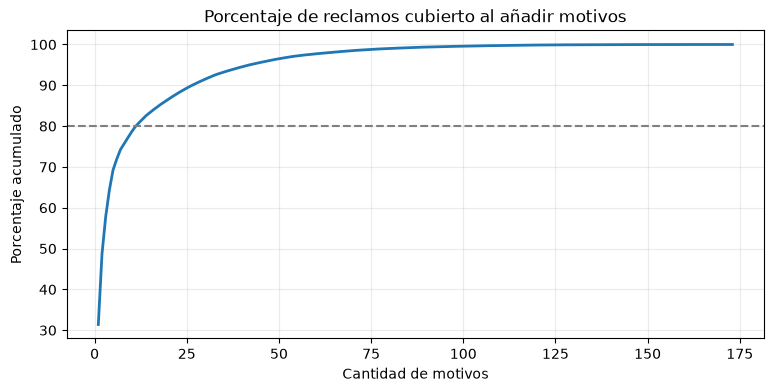

In [38]:
t1_counts = issue_counts.sort_values(ascending=False)
t1_total = t1_counts.sum()
t1_rank = pd.DataFrame({
    "motivo": t1_counts.index,
    "reclamos": t1_counts.to_numpy(),
})
t1_rank["porcentaje"] = 100 * t1_rank["reclamos"] / t1_total
t1_rank["porcentaje acumulado"] = t1_rank["porcentaje"].cumsum()

top_values = [1, 3, 10, 25, 50, 100, len(t1_rank)]
concentration_rows = []
for top_n in top_values:
    concentration_rows.append({
        "clases principales": top_n,
        "reclamos cubiertos": t1_rank.iloc[:top_n]["reclamos"].sum(),
        "porcentaje del total": t1_rank.iloc[:top_n]["porcentaje"].sum(),
    })
t1_concentration = pd.DataFrame(concentration_rows)
t1_concentration["reclamos cubiertos"] = t1_concentration["reclamos cubiertos"].map("{:,}".format)
t1_concentration["porcentaje del total"] = t1_concentration["porcentaje del total"].map("{:.2f}%".format)
display(t1_concentration)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(t1_rank) + 1), t1_rank["porcentaje acumulado"], linewidth=2)
ax.axhline(80, color="gray", linestyle="--")
ax.set(title="Porcentaje de reclamos cubierto al añadir motivos", xlabel="Cantidad de motivos", ylabel="Porcentaje acumulado")
ax.grid(alpha=0.25)
plt.show()

In [39]:
thresholds = [100, 1_000, 10_000]
rare_rows = []
for threshold in thresholds:
    rare_mask = t1_counts < threshold
    rare_rows.append({
        "menos de": f"{threshold:,} reclamos",
        "cantidad de motivos": rare_mask.sum(),
        "reclamos reunidos": t1_counts[rare_mask].sum(),
        "porcentaje del total": 100 * t1_counts[rare_mask].sum() / t1_total,
    })
rare_table = pd.DataFrame(rare_rows)
rare_display = rare_table.copy()
rare_display["reclamos reunidos"] = rare_display["reclamos reunidos"].map("{:,}".format)
rare_display["porcentaje del total"] = rare_display["porcentaje del total"].map("{:.2f}%".format)
display(rare_display)

least_frequent = t1_rank.tail(15).sort_values("reclamos")[["motivo", "reclamos"]]
display(least_frequent)

,menos de,cantidad de motivos,reclamos reunidos,porcentaje del total
0,100 reclamos,31,"1,292",0.03%
1,"1,000 reclamos",84,"25,077",0.65%
2,"10,000 reclamos",135,"228,450",5.95%


,motivo,reclamos
172,Lender damaged or destroyed property,1
171,Lender damaged or destroyed vehicle,2
170,Lender sold the property,3
169,Problem with an overdraft,4
168,Lost or stolen refund,7
167,Property was damaged or destroyed property,9
166,Shopping for a line of credit,10
165,Disclosures,13
164,Managing the line of credit,16
161,Property was sold,17


### 2. T2, T3 y T4 — Resultados con dos opciones

Estos objetivos tienen dos clases: positivo y negativo. Para T2 y T3 se excluyen del porcentaje los casos cuyo resultado quedó desconocido.

In [40]:
binary_balance = target_table.copy()
binary_balance["negativos por positivo"] = binary_balance["negativos"] / binary_balance["positivos"]
binary_balance["acierto si siempre predice negativo"] = (
    100 * binary_balance["negativos"] / (binary_balance["positivos"] + binary_balance["negativos"])
)
binary_display = binary_balance[[
    "objetivo", "positivos", "negativos",
    "negativos por positivo", "acierto si siempre predice negativo",
]].copy()
binary_display["positivos"] = binary_display["positivos"].map("{:,}".format)
binary_display["negativos"] = binary_display["negativos"].map("{:,}".format)
binary_display["negativos por positivo"] = binary_display["negativos por positivo"].map("{:.1f}".format)
binary_display["acierto si siempre predice negativo"] = binary_display["acierto si siempre predice negativo"].map("{:.2f}%".format)
display(binary_display)

,objetivo,positivos,negativos,negativos por positivo,acierto si siempre predice negativo
0,T2 — algún relief,"1,273,365","2,548,866",2.0,66.69%
1,T3 — relief monetario,"98,150","3,724,081",37.9,97.43%
2,T4 — respuesta no oportuna CFPB,"42,615","3,794,569",89.0,98.89%


### 3. Comparación mínima obligatoria

Un **baseline** es una regla sencilla que sirve como punto de comparación. Un modelo complejo solo aporta valor si supera estas reglas simples.

In [41]:
naive_rows = [
    {
        "objetivo": "T1 — motivo",
        "regla simple": "predecir siempre el motivo más frecuente",
        "resultado aparente": 100 * t1_counts.iloc[0] / t1_total,
    },
    {
        "objetivo": "T1 — motivo entre tres opciones",
        "regla simple": "ofrecer siempre los mismos tres motivos frecuentes",
        "resultado aparente": 100 * t1_counts.iloc[:3].sum() / t1_total,
    },
]
for _, row in binary_balance.iterrows():
    naive_rows.append({
        "objetivo": row["objetivo"],
        "regla simple": "predecir siempre negativo",
        "resultado aparente": row["acierto si siempre predice negativo"],
    })
naive_table = pd.DataFrame(naive_rows)
naive_table["resultado aparente"] = naive_table["resultado aparente"].map("{:.2f}%".format)
display(naive_table)

,objetivo,regla simple,resultado aparente
0,T1 — motivo,predecir siempre el motivo más frecuente,31.40%
1,T1 — motivo entre tres opciones,ofrecer siempre los mismos tres motivos frecue...,57.81%
2,T2 — algún relief,predecir siempre negativo,66.69%
3,T3 — relief monetario,predecir siempre negativo,97.43%
4,T4 — respuesta no oportuna CFPB,predecir siempre negativo,98.89%


### 4. Cómo evaluaremos los modelos

- **Porcentaje de aciertos:** cuántos casos se clasifican correctamente. Se reportará, pero no bastará por sí solo.
- **Precisión:** de los casos marcados como positivos, qué proporción era realmente positiva.
- **Cobertura o recall:** de todos los positivos reales, qué proporción encontró el modelo.
- **F1:** combina precisión y cobertura en un solo número.
- **Macro-F1 para T1:** calcula F1 por cada motivo y luego da el mismo peso a todos; así los motivos frecuentes no ocultan a los pequeños.
- **Top-3 para T1:** comprueba si el motivo correcto aparece entre las tres sugerencias del sistema. Debe compararse contra la regla que siempre ofrece los tres motivos más frecuentes.
- **PR-AUC para T2–T4:** resume el intercambio entre precisión y cobertura cuando cambiamos la probabilidad mínima exigida para marcar un caso como positivo. Debe compararse contra la proporción real de positivos.


## Resultado de E7

- T1 tiene 173 motivos originales. Los 10 más frecuentes reúnen 78.55% de los reclamos, mientras 31 motivos tienen menos de 100 ejemplos cada uno.
- Una regla que siempre predice el motivo principal acertaría 31.40%. Una que siempre ofrece los mismos tres motivos alcanzaría 57.81% en top-3 sin leer la narrativa.
- T2 tiene dos casos negativos por cada positivo. El desbalance es mucho mayor en T3, con 37.9 negativos por positivo, y T4, con 89.0.
- Predecir siempre negativo produciría 97.43% de aciertos en T3 y 98.89% en T4, pero no encontraría ningún positivo. Por eso el porcentaje de aciertos no será la métrica principal.
- La futura agrupación de motivos deberá basarse en significado y uso histórico, no hacerse únicamente para mejorar una métrica.
- Todos los modelos deberán superar las reglas simples y reportar resultados que den visibilidad a las clases poco frecuentes.
- El siguiente paso, sujeto a aprobación, es **E8: cambios entre periodos anteriores y posteriores**.

## E8 — Cambios entre periodos

**Pregunta:** ¿Los productos, motivos y resultados mantienen la misma distribución con el paso del tiempo?

Llamamos **cambio temporal** a una variación en la frecuencia de categorías o resultados entre periodos. Si el cambio es grande, aprender del pasado puede no ser suficiente para predecir reclamos nuevos.

### 1. Periodos de análisis y periodos reservados

Usaremos tres periodos para entender los cambios: contexto histórico, referencia reciente y comparación posterior. Solo contaremos las filas de los periodos reservados; no revisaremos todavía sus productos, motivos ni resultados.

In [42]:
del group_profile, exact_counts, normalized_counts, exact_hash, normalized_hash
gc.collect()

period_order = [
    "2015–2022 — contexto histórico",
    "2023–2024 — referencia reciente",
    "2025-H1 — comparación",
    "2025-H2 — reservado",
    "2026 parcial — reservado",
]
analysis_periods = period_order[:3]
received_dates = identity["Date received"]
period = pd.Series(pd.NA, index=identity.index, dtype="string")
period.loc[received_dates < "2023-01-01"] = period_order[0]
period.loc[received_dates.between("2023-01-01", "2024-12-31")] = period_order[1]
period.loc[received_dates.between("2025-01-01", "2025-06-30")] = period_order[2]
period.loc[received_dates.between("2025-07-01", "2025-12-31")] = period_order[3]
period.loc[received_dates >= "2026-01-01"] = period_order[4]
assert period.notna().all()

period_counts = period.value_counts().reindex(period_order).rename_axis("periodo").reset_index(name="reclamos")
period_counts["reclamos"] = period_counts["reclamos"].map("{:,}".format)
display(period_counts)

,periodo,reclamos
0,2015–2022 — contexto histórico,"1,206,176"
1,2023–2024 — referencia reciente,"1,301,794"
2,2025-H1 — comparación,"695,184"
3,2025-H2 — reservado,"526,872"
4,2026 parcial — reservado,"107,158"


In [43]:
temporal_columns = [
    "Product", "Issue",
    "Company response to consumer", "Timely response?",
]
temporal_data = pd.read_parquet(RAW_PATH, columns=temporal_columns, dtype_backend="pyarrow")
temporal_data["period"] = period
analysis_data = temporal_data[temporal_data["period"].isin(analysis_periods)].copy()
analysis_data.shape

(3203154, 5)

### 2. Categorías disponibles en cada periodo

Una categoría nueva en 2025-H1 no puede aprenderse directamente si no aparece en 2023–2024. Una categoría ausente puede indicar un cambio de nombre, una categoría retirada o simplemente pocos casos.

In [44]:
taxonomy_rows = []
for current_period in analysis_periods:
    current = analysis_data[analysis_data["period"] == current_period]
    taxonomy_rows.append({
        "periodo": current_period,
        "productos observados": current["Product"].nunique(),
        "motivos observados": current["Issue"].nunique(),
    })
display(pd.DataFrame(taxonomy_rows))

change_rows = []
for column, name in [("Product", "producto"), ("Issue", "motivo")]:
    reference_values = set(analysis_data.loc[analysis_data["period"] == analysis_periods[1], column].dropna().unique())
    comparison_values = set(analysis_data.loc[analysis_data["period"] == analysis_periods[2], column].dropna().unique())
    new_values = sorted(comparison_values - reference_values)
    absent_values = sorted(reference_values - comparison_values)
    change_rows.append({
        "categoría": name,
        "nuevas en 2025-H1": len(new_values),
        "lista de nuevas": " | ".join(new_values) if new_values else "ninguna",
        "presentes en 2023–2024 y ausentes en 2025-H1": len(absent_values),
        "lista de ausentes": " | ".join(absent_values) if absent_values else "ninguna",
    })
display(pd.DataFrame(change_rows))

,periodo,productos observados,motivos observados
0,2015–2022 — contexto histórico,18,160
1,2023–2024 — referencia reciente,14,92
2,2025-H1 — comparación,11,87


,categoría,nuevas en 2025-H1,lista de nuevas,presentes en 2023–2024 y ausentes en 2025-H1,lista de ausentes
0,producto,0,ninguna,3,Credit card or prepaid card | Credit reporting...
1,motivo,0,ninguna,5,Excessive fees | Lost or stolen check | Lost o...


### 3. Categorías que más cambian

Medimos el cambio en **puntos porcentuales**. Por ejemplo, pasar de 10% a 13% es un aumento de 3 puntos porcentuales.

,2023–2024,2025-H1,cambio en puntos
Product,,,
"Credit reporting, credit repair services, or other personal consumer reports",17.26%,0.00%,-17.26%
Credit reporting or other personal consumer reports,57.98%,74.28%,16.30%
"Money transfer, virtual currency, or money service",1.44%,7.71%,6.27%
Credit card or prepaid card,1.63%,0.00%,-1.63%
Debt collection,8.13%,7.16%,-0.97%
Mortgage,1.93%,0.98%,-0.95%
Credit card,3.71%,2.83%,-0.88%
Vehicle loan or lease,1.15%,0.78%,-0.36%
"Payday loan, title loan, or personal loan",0.22%,0.00%,-0.22%


,2023–2024,2025-H1,cambio en puntos
Issue,,,
Other transaction problem,0.24%,6.12%,5.88%
Problem with a credit reporting company's investigation into an existing problem,5.51%,0.00%,-5.51%
Incorrect information on your report,34.56%,38.62%,4.07%
Improper use of your report,21.53%,20.29%,-1.24%
Problem with a company's investigation into an existing problem,13.74%,14.79%,1.05%
Problem caused by your funds being low,0.33%,1.14%,0.81%
Trouble during payment process,1.05%,0.54%,-0.51%
Written notification about debt,2.15%,1.68%,-0.48%
Attempts to collect debt not owed,3.78%,3.32%,-0.46%


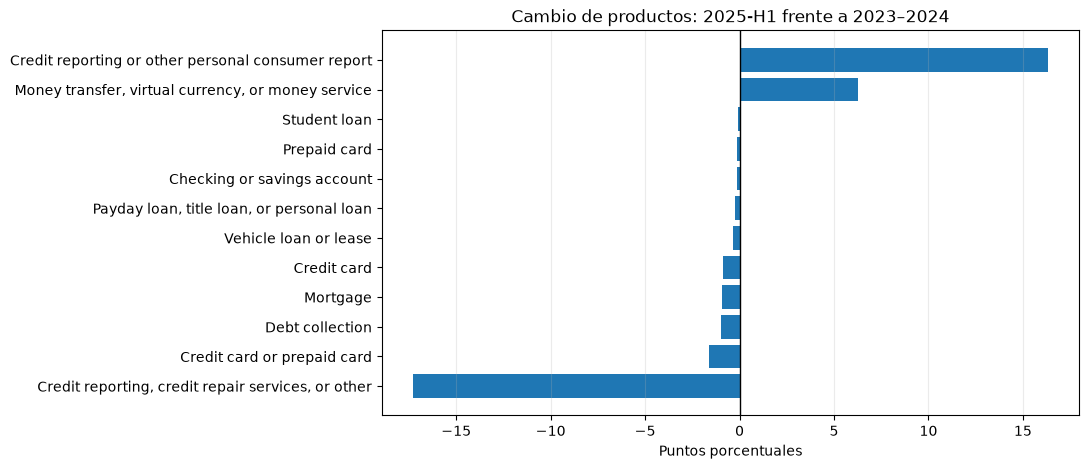

In [45]:
def period_shares(column):
    counts = pd.crosstab(analysis_data["period"], analysis_data[column])
    counts = counts.reindex(analysis_periods, fill_value=0)
    return counts.div(counts.sum(axis=1), axis=0) * 100

product_shares = period_shares("Product")
issue_shares = period_shares("Issue")

def largest_changes(shares, count=12):
    result = pd.DataFrame({
        "2023–2024": shares.loc[analysis_periods[1]],
        "2025-H1": shares.loc[analysis_periods[2]],
    })
    result["cambio en puntos"] = result["2025-H1"] - result["2023–2024"]
    return result.reindex(result["cambio en puntos"].abs().sort_values(ascending=False).index).head(count)

product_changes = largest_changes(product_shares)
issue_changes = largest_changes(issue_shares, count=15)
product_change_display = product_changes.copy()
issue_change_display = issue_changes.copy()
for column in product_change_display.columns:
    product_change_display[column] = product_change_display[column].map("{:.2f}%".format)
for column in issue_change_display.columns:
    issue_change_display[column] = issue_change_display[column].map("{:.2f}%".format)
display(product_change_display)
display(issue_change_display)

plot_data = product_changes.sort_values("cambio en puntos")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_data.index.str.slice(0, 50), plot_data["cambio en puntos"])
ax.axvline(0, color="black", linewidth=1)
ax.set(title="Cambio de productos: 2025-H1 frente a 2023–2024", xlabel="Puntos porcentuales", ylabel="")
ax.grid(axis="x", alpha=0.25)
plt.show()

### 4. Frecuencia de T2, T3 y T4 por periodo

El porcentaje positivo es la cantidad de casos que cumplen la condición dividida entre los casos con resultado conocido. No es una métrica del modelo: describe lo que ocurrió en los datos. Aplicamos exactamente las reglas definidas en E4.

Cada panel usa su propia escala para que T3 y T4 puedan verse. Por eso deben compararse los periodos dentro del mismo panel, no la altura de T2 contra T3 o T4. El valor exacto aparece sobre cada barra.

objetivo,T2,T3,T4
periodo,,,
2015–2022 — contexto histórico,20.183%,4.151%,1.757%
2023–2024 — referencia reciente,43.226%,2.010%,0.535%
2025-H1 — comparación,38.722%,1.078%,0.888%


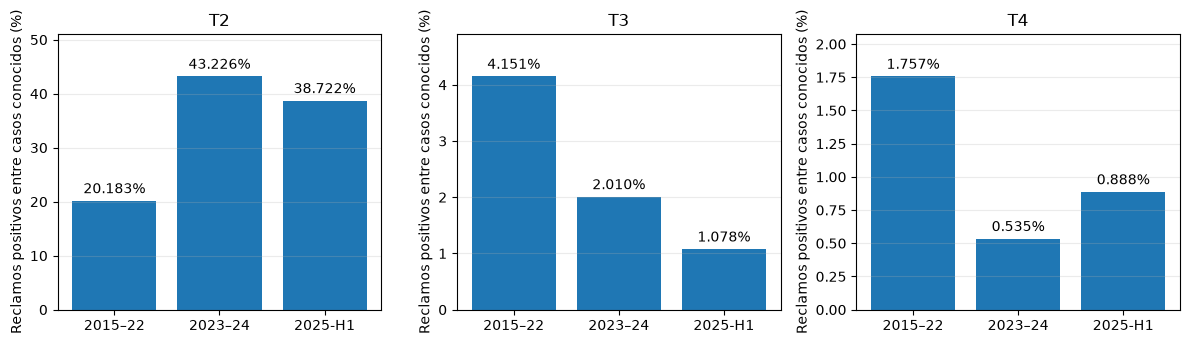

In [46]:
response = analysis_data["Company response to consumer"]
explicit_responses = [
    "Closed with monetary relief",
    "Closed with non-monetary relief",
    "Closed with explanation",
]
eligible = response.isin(explicit_responses)
period_targets = pd.DataFrame({"periodo": analysis_data["period"]})
period_targets["T2"] = pd.Series(pd.NA, index=analysis_data.index, dtype="boolean")
period_targets.loc[eligible, "T2"] = response[eligible].isin(explicit_responses[:2]).to_numpy()
period_targets["T3"] = pd.Series(pd.NA, index=analysis_data.index, dtype="boolean")
period_targets.loc[eligible, "T3"] = response[eligible].eq(explicit_responses[0]).to_numpy()
period_targets["T4"] = analysis_data["Timely response?"].eq("No").astype("boolean")

target_period_rows = []
for current_period in analysis_periods:
    current = period_targets[period_targets["periodo"] == current_period]
    for target in ["T2", "T3", "T4"]:
        known = current[target].notna()
        target_period_rows.append({
            "periodo": current_period,
            "objetivo": target,
            "casos conocidos": known.sum(),
            "tasa positiva": 100 * current.loc[known, target].mean(),
        })
target_period_table = pd.DataFrame(target_period_rows)
target_rate_table = target_period_table.pivot(index="periodo", columns="objetivo", values="tasa positiva").reindex(analysis_periods)
target_rate_display = target_rate_table.copy()
for column in target_rate_display.columns:
    target_rate_display[column] = target_rate_display[column].map("{:.3f}%".format)
display(target_rate_display)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, target in zip(axes, ["T2", "T3", "T4"]):
    values = target_rate_table[target]
    bars = ax.bar(["2015–22", "2023–24", "2025-H1"], values)
    ax.bar_label(bars, labels=[f"{value:.3f}%" for value in values], padding=3)
    ax.set(
        title=target,
        ylabel="Reclamos positivos entre casos conocidos (%)",
        ylim=(0, values.max() * 1.18),
    )
    ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## Resultado de E8

- 2025-H1 no contiene productos ni motivos nuevos respecto de 2023–2024. Sin embargo, tres productos y cinco motivos presentes en 2023–2024 no aparecen en 2025-H1.
- Parte del cambio parece provenir de nombres reemplazados: una categoría antigua de credit reporting cae 17.26 puntos y otra categoría relacionada sube 16.30 puntos. Esto justifica agrupar etiquetas históricas equivalentes antes de modelar.
- `Money transfer, virtual currency, or money service` aumenta 6.27 puntos y `Other transaction problem` aumenta 5.88; estos cambios deberán revisarse después de corregir los cambios de nombres.
- Entre 2023–2024 y 2025-H1, T2 baja de 43.226% a 38.722%, T3 baja de 2.010% a 1.078% y T4 sube de 0.535% a 0.888%.
- El periodo 2015–2022 tiene categorías y tasas muy diferentes. Servirá como contexto histórico y no se combinará automáticamente con años recientes.
- La evaluación debe respetar el orden temporal porque tanto las categorías como los resultados cambian.
- En este paso solo contamos las filas de 2025-H2 y 2026; no usamos sus productos, motivos ni resultados para tomar decisiones.
- El siguiente paso, sujeto a aprobación, es **E9: acordar transformaciones y divisiones temporales**.

## E9 — Contrato de transformación y evaluación

**Pregunta:** ¿Qué cambios están justificados por el EDA y cómo evitaremos usar información que no existiría al recibir un reclamo nuevo?

Un **contrato** es una lista explícita de reglas que deberán cumplir las transformaciones. E9 todavía no modifica el archivo: define qué construiremos y cómo comprobaremos que está bien hecho.

### 1. Principios acordados

1. El archivo original nunca se modifica.
2. Todas las filas se conservan; los textos repetidos se agrupan, no se borran.
3. Solo se usan como entrada datos disponibles al recibir el reclamo.
4. Las categorías históricas equivalentes se agrupan mediante un mapa explícito y revisable.
5. Las divisiones respetan el tiempo.
6. Todo aprendizaje de vocabulario, escalas o representaciones se hace únicamente con entrenamiento.
7. Cada archivo generado queda identificado por DVC y cada regla queda registrada en Git.

### 2. Uso permitido de las columnas

Definimos el **momento de predicción (`t0`)** como el instante posterior a la recepción y al enrutamiento inicial de CFPB, pero anterior a cualquier respuesta de la empresa. Solo usaremos campos demostrablemente disponibles en ese momento. La narrativa pública anonimizada es una aproximación al texto de ingreso; este archivo tampoco representa reclamos sin narrativa publicada.

| Columnas | Uso acordado | Razón |
|---|---|---|
| `Consumer complaint narrative` | Entrada principal | Aproximación pública y anonimizada al texto recibido |
| `Product`, `Sub-product` | Entradas | Contexto declarado del reclamo |
| `Company` | Entrada opcional; probar con y sin ella | Útil en CFPB, pero puede no transferirse a un banco |
| `Date received` | Orden temporal y variables de calendario justificadas | Disponible al ingreso |
| `State`, `ZIP code` | Auditoría; no usar por defecto | Riesgo de privacidad, sesgo y transferencia |
| `Tags` | Auditoría; no usar por defecto | 90.42% ausente y contiene grupos sensibles |
| `Submitted via` | Excluir | Es `Web` en 100% del archivo |
| `Complaint ID` | Identificador; nunca entrada del modelo | No describe el contenido del reclamo |
| `Issue` | Construir T1 | Es el resultado que T1 intenta predecir |
| `Sub-issue` | Auditoría y posible trabajo futuro | No forma parte de los objetivos actuales |
| `Company response to consumer` | Construir T2 y T3 | Se conoce después de la respuesta |
| `Timely response?` | Construir T4 | Se conoce después de la respuesta |
| `Company public response` | Excluir como entrada | Texto posterior que puede revelar el resultado |
| `Date sent to company` | Auditoría del proceso CFPB | No es fecha de resolución ni dato inicial seguro |

### 3. Construcción de T1–T4

**T1 es una clasificación asistida con varias opciones.** Reproduce el `Issue` canónico ocultándolo de las entradas. Sirve para sugerir o validar el motivo; no predice un resultado futuro ni un equipo interno del banco. Una etiqueta original sin mapa aprobado quedará como error pendiente de revisión, no como una categoría genérica.

T2–T4 tienen dos resultados posibles:

| Objetivo | Positivo | Negativo | Desconocido |
|---|---|---|---|
| T2 — relief registrado | Monetary o non-monetary relief | Closed with explanation | Closed, In progress, Untimely response o nulo |
| T3 — relief monetario | Monetary relief | Non-monetary relief o explanation | Closed, In progress, Untimely response o nulo |
| T4 — no oportuna CFPB | `Timely response? = No` | `Timely response? = Yes` | Ninguno en el archivo actual |

T2 identifica relief registrado por categorías CFPB. No equivale a resolución, satisfacción del consumidor ni cualquier tipo de solución. Será una señal auxiliar. T3 responde de forma más directa al interés por compensación monetaria, pero continúa siendo una aproximación CFPB y no un reembolso bancario confirmado.

Cada objetivo tendrá su propia máscara de elegibilidad: `known_T1`, `known_T2`, `known_T3` y `known_T4`. Un reclamo puede ser evaluable para un objetivo y desconocido para otro. T1 requiere un motivo incluido en el mapa congelado; T2 y T3 requieren una respuesta explícita; T4 requiere `Yes` o `No`.

T2–T4 también requieren una política de **maduración**, es decir, tiempo suficiente para que la respuesta histórica quede registrada. La fecha de extracción del archivo no está documentada. Hasta recuperarla o definir una ventana conservadora, 2026 no se usará para evaluar T2–T4; solo podrá analizarse T1 y la disponibilidad de entradas.

### 4. Tratamiento del texto

Conservaremos dos versiones:

- **Narrativa original:** se mantiene para auditoría y para modelos de texto.
- **Narrativa normalizada:** aplica `text_normalizer_v1` en orden: NFKC; `casefold`; patrón `\bx{2,}\b` reemplazado literalmente por `<redacted>`; `\s+` reemplazado por un espacio; y `strip`.

La entrada y salida serán texto Unicode y el hash usará su codificación UTF-8. La narrativa normalizada producirá un identificador estable mediante SHA-256, un cálculo que genera la misma huella para el mismo texto. La versión del normalizador se guardará junto al hash. No eliminaremos números, puntuación ni palabras comunes sin un experimento que demuestre beneficio.

Para textos largos compararemos recorte y división en fragmentos. La decisión se tomará con entrenamiento y validación, nunca con los periodos reservados.

### 5. Agrupación de categorías históricas

E8 mostró etiquetas antiguas que desaparecen mientras etiquetas relacionadas crecen. Crearemos un archivo de configuración que asigne cada producto y motivo original a una categoría común.

Reglas:

- el mapa será explícito y versionado;
- cada etiqueta original tendrá una única salida;
- durante la construcción con entrenamiento y validación, una etiqueta sin mapa producirá un error visible;
- no habrá categoría genérica silenciosa durante la construcción del mapa;
- los grupos semánticos podrán aportar evidencia, pero no crearán automáticamente la taxonomía;
- el mapa deberá quedar identificado como propuesta hasta recibir revisión de negocio;
- el mapa y los pares válidos `Product`–`Issue` se congelarán antes de evaluar 2025-H2;
- después de congelarlo, un T1 no visto tendrá `known_T1=False`, se reportará y no actualizará el mapa;
- después de congelarlo, una categoría de entrada no vista usará `__UNKNOWN__` de forma explícita.


### 6. División temporal propuesta

Un **periodo reservado** o `holdout` se guarda para una comprobación final y no se usa para escoger transformaciones o modelos. **Fuera de periodo** u OOD describe datos posteriores y parcialmente diferentes a los usados para desarrollar el sistema.

| Uso | Fechas | Filas | Decisión |
|---|---|---:|---|
| Contexto histórico | 2015–2022 | 1,206,176 | Analizar; no incluir por defecto en entrenamiento |
| Entrenamiento | 2023–2024 | 1,301,794 | Aprender transformaciones y modelos |
| Validación | 2025-H1 | 695,184 | Elegir opciones sin reajustarlas con este periodo |
| Reservado final candidato | 2025-H2 | 526,872 | No consultar durante el desarrollo |
| Fuera de periodo parcial | 2026 hasta 2026-07-27 | 107,158 | T1 y entradas; T2–T4 bloqueados hasta definir maduración |

Un experimento anterior ya consultó 25,000 IDs de 2025-H2. Deberemos recuperar esos IDs y excluir también todos los registros que compartan con ellos el mismo grupo de texto normalizado. El tamaño final elegible solo podrá calcularse después de cerrar esos grupos; por eso no asumimos que sea 501,872. Si no recuperamos la lista completa, 2025-H2 se declarará contaminado y no se presentará como evaluación final intacta.

Cada periodo evaluado tendrá dos vistas:

- **Completa elegible:** conserva todos los casos permitidos después de excluir contaminación conocida y resultados no disponibles. No representa todos los reclamos CFPB, porque el archivo solo contiene casos con narrativa publicada.
- **Sin repetición compartida:** validación excluye grupos vistos en entrenamiento; la evaluación final excluye grupos vistos en entrenamiento, validación y los 25,000 casos ya consultados. No se eliminan repeticiones internas del propio periodo.

Para ambas vistas reportaremos cantidad de filas, frecuencia de resultados y cobertura de categorías. No moveremos reclamos futuros hacia entrenamiento para mantener juntos los grupos: el orden temporal tiene prioridad.

### 7. Entrega de esta rama a modelado

La rama EDA terminará con una tabla preparada que conserve:

- columnas originales necesarias para auditoría;
- tipos correctos;
- producto y motivo agrupados mediante el mapa aprobado;
- T1–T4 y una máscara de elegibilidad separada para cada objetivo;
- narrativa original, narrativa normalizada y hash estable;
- periodo asignado;
- indicador de los 25,000 casos ya consultados y cierre por grupo;
- máscaras para la vista completa elegible y la vista sin repetición compartida.

TF-IDF, BGE, FAISS y los modelos se implementarán en `Modeling/pipaber`. Su propuesta está documentada en `docs/modelos.md`.

### 8. Flujo reproducible con DVC

```mermaid
flowchart LR
    A[Datos originales] --> B[Tipos correctos]
    B --> C[Categorías agrupadas]
    C --> D[Objetivos, periodos y grupos de texto]
    D --> E[Tabla preparada para modelado]
```

DVC guardará los archivos generados y `dvc.yaml` declarará cómo reconstruirlos. Sus dependencias incluirán el archivo original, el mapa de categorías, `text_normalizer_v1`, los límites temporales y la lista de casos ya consultados. `dvc.lock` registrará las huellas de esas dependencias y salidas; `uv.lock` fijará las versiones del entorno Python. Git guardará código, reglas y configuración.

### 9. Comprobaciones obligatorias

Cada transformación deberá comprobar automáticamente que:

- conserva exactamente el conjunto de IDs del archivo original en la tabla preparada;
- mantiene los IDs únicos y detecta cualquier sustitución o pérdida;
- convierte las fechas sin producir nuevos nulos;
- crea divisiones temporales disjuntas y que cubren todas las filas;
- respeta los límites exactos de cada periodo;
- asigna todas las categorías mediante un mapa conocido y valida pares producto–motivo;
- falla ante categorías sin mapa durante la construcción con entrenamiento y validación;
- después de congelar el mapa, convierte entradas no vistas a `__UNKNOWN__` y objetivos T1 no vistos a `known_T1=False`;
- reproduce por periodo los conteos de cada motivo en T1 y los positivos, negativos y desconocidos de T2–T4;
- crea y valida `known_T1`–`known_T4` por separado;
- bloquea la evaluación de T2–T4 cuando el periodo no cumple la política de maduración;
- valida las reglas T1–T4 con ejemplos pequeños que incluyan nulos;
- aplica exactamente `text_normalizer_v1` y demuestra que no altera `xx` dentro de palabras;
- normaliza de forma idempotente: normalizar dos veces produce el mismo resultado;
- genera el mismo SHA-256 desde texto UTF-8 al repetir la ejecución y registra la versión del normalizador;
- no incluye columnas posteriores a `t0` como entradas;
- identifica los 25,000 casos de 2025-H2 ya consultados y cierra su exclusión por grupo;
- no comparte hashes con los periodos de referencia en la vista sin repetición;
- reporta filas, frecuencia de resultados y cobertura de categorías para cada vista.

## Resultado de E9

E9 convierte los hallazgos del EDA en reglas verificables. Después de aprobarlo podremos implementar las transformaciones una por una mediante DVC, sin modificar el archivo original y sin comenzar todavía el modelado.

El siguiente paso, sujeto a aprobación, es **E10: resumir hallazgos, decisiones y limitaciones del EDA**.

## E10 — Cierre del análisis exploratorio

**Pregunta:** ¿Qué aprendimos, qué valor puede habilitar y qué falta antes de modelar?

El resumen para una lectura rápida está en [`docs/resumen-eda.md`](../docs/resumen-eda.md). La propuesta futura de modelos está en [`docs/modelos.md`](../docs/modelos.md).

### Historia de valor

El stakeholder explicó que el centro de atención ya clasifica reclamos mediante reglas. Nuestro sistema no intenta reemplazarlas. La propuesta es añadir una segunda capa que pueda:

1. sugerir o validar el motivo CFPB desde la narrativa;
2. estimar señales históricas de relief monetario y respuesta no oportuna;
3. mostrar reclamos anteriores con significado parecido;
4. agrupar narrativas relacionadas que las reglas actuales tratan por separado;
5. alertar cuando un patrón aumenta más de lo esperado;
6. entregar evidencia a una persona, que conserva la decisión final.

El EDA muestra por qué esta capa debe considerar tiempo, cambios de taxonomía, clases poco frecuentes y plantillas repetidas. Ignorarlos produciría métricas engañosas y falsas alertas.

### Lo que este EDA sí entrega

- revisión reproducible de las 3,837,184 filas;
- definición y límites de T1–T4;
- evidencia sobre calidad, longitud y repetición textual;
- evidencia sobre desbalance y cambios temporales;
- reglas de disponibilidad para evitar fuga de información;
- normalización `text_normalizer_v1`;
- propuesta de periodos y evaluaciones;
- contrato de transformación y pruebas obligatorias;
- propuesta separada de modelos y patrones emergentes.

### Lo que todavía no entrega

- datos transformados o una tabla preparada;
- mapa canónico implementado;
- `dvc.yaml` con etapas de transformación;
- features TF-IDF o embeddings;
- modelos entrenados o métricas de desempeño;
- validación con datos internos de un banco;
- detección de fraude confirmado o medición del plazo de 15 días.

### Estado en CRISP-DM

**CRISP-DM** es una forma de organizar proyectos de datos en etapas. Con E10 quedan documentadas:

1. **Comprensión del negocio:** qué necesita el triaje y qué no puede responder CFPB.
2. **Comprensión de los datos:** estructura, calidad, texto, repeticiones, desbalance y tiempo.

La siguiente etapa será **preparación de datos**: implementar el contrato E9 mediante transformaciones pequeñas, pruebas y DVC. El modelado comenzará después, en `Modeling/pipaber`.

## Resultado de E10

El EDA queda listo para revisión final. Después de aprobar E10, el siguiente bloque de trabajo será implementar la preparación de datos definida en E9. Cada transformación importante se ejecutará, validará, versionará con DVC y publicará antes de avanzar.